0. Librairies

In [403]:
# core scientific stack
import pandas as pd
import numpy as np

# Preprocessing
#import imblearn
from sklearn.preprocessing import MinMaxScaler

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML: Data Splitting & Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

import warnings
warnings.filterwarnings('ignore')

# constant
RSEED = 10

1. Data Import

In [404]:
# import data from CSV
data_raw = pd.read_csv('data/kickstarter_projects.csv')

In [405]:
# check import
data_raw.head()

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [406]:
# renaming columns with lower case
data_raw.columns = data_raw.columns.str.lower()
data_raw.head()

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [407]:
# 374 853 rows
# 11 columns
data_raw.shape

(374853, 11)

In [408]:
# check data types
data_raw.dtypes

id              int64
name           object
category       object
subcategory    object
country        object
launched       object
deadline       object
goal            int64
pledged         int64
backers         int64
state          object
dtype: object

In [409]:
# check "category"
data_raw.category.nunique()

15

In [410]:
data_raw.category.value_counts()

category
Film & Video    62694
Music           49529
Publishing      39378
Games           35225
Technology      32562
Design          30065
Art             28151
Food            24599
Fashion         22812
Theater         10911
Comics          10819
Photography     10778
Crafts           8809
Journalism       4754
Dance            3767
Name: count, dtype: int64

In [411]:
# check "subcategory"
data_raw.subcategory.nunique()

159

In [412]:
data_raw.subcategory.value_counts()

subcategory
Product Design     22310
Documentary        16138
Tabletop Games     14178
Music              13339
Shorts             12357
                   ...  
Residencies           69
Letterpress           49
Chiptune              35
Literary Spaces       27
Taxidermy             13
Name: count, Length: 159, dtype: int64

In [413]:
data_raw.country.nunique()

22

In [414]:
data_raw.country.value_counts()

country
United States     292618
United Kingdom     33671
Canada             14756
Australia           7839
Germany             4171
France              2939
Italy               2878
Netherlands         2868
Spain               2276
Sweden              1757
Mexico              1752
New Zealand         1447
Denmark             1113
Ireland              811
Switzerland          760
Norway               708
Hong Kong            618
Belgium              617
Austria              597
Singapore            555
Luxembourg            62
Japan                 40
Name: count, dtype: int64

In [415]:
data_raw.columns

Index(['id', 'name', 'category', 'subcategory', 'country', 'launched',
       'deadline', 'goal', 'pledged', 'backers', 'state'],
      dtype='object')

In [416]:
# 11 columns: 
# id
# name
# category: (15)
# subcategory: (159)
# country: Country of product origin (22)
# launched: Date the project was launched
# deadline: Deadline for crowdfunding
# goal: Amount of money the creater needs to complete the project (USD)
# pledged: Amount of money pledged to by the crowd (USD)
# backers: Number of backers
# state: Current condition the project is in (as of 2018-01-02)

2. Data cleaning and filtering

In [417]:
# we don't really need the name of the projects 
# because some projects have the same name but different IDs
# 374 853 unique ID
# 372 061 unique names
data_raw.id.unique().size

374853

In [418]:
data_raw.name.unique().size

372061

In [419]:
# let's drop the name and id
data = data_raw.drop(columns=['name','id'], axis = 1)
data.head()

,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed


In [420]:
# let's add year column to have a better overview of year launched project year
data['year'] = pd.DatetimeIndex(data['launched']).year
data.head()

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year
0,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed,2009
1,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed,2009
2,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful,2009
3,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful,2009
4,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed,2009


In [421]:
data['year'].unique()

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
      dtype=int32)

In [422]:
# convert deadline and launched to dates
data['launched'] = pd.to_datetime(data['launched']).dt.normalize()
data['deadline'] = pd.to_datetime(data['deadline']).dt.normalize()
data['deadline'], data['launched']

(0        2009-05-31
 1        2009-07-20
 2        2009-05-03
 3        2009-07-14
 4        2009-05-26
             ...    
 374848   2018-01-16
 374849   2018-02-09
 374850   2018-01-16
 374851   2018-02-01
 374852   2018-01-26
 Name: deadline, Length: 374853, dtype: datetime64[ns],
 0        2009-04-21
 1        2009-04-23
 2        2009-04-24
 3        2009-04-25
 4        2009-04-27
             ...    
 374848   2018-01-02
 374849   2018-01-02
 374850   2018-01-02
 374851   2018-01-02
 374852   2018-01-02
 Name: launched, Length: 374853, dtype: datetime64[ns])

In [423]:
data['deadline'].max(), data['deadline'].min()

(Timestamp('2018-03-03 00:00:00'), Timestamp('2009-05-03 00:00:00'))

In [424]:
data['launched'].max(), data['launched'].min()

(Timestamp('2018-01-02 00:00:00'), Timestamp('2009-04-21 00:00:00'))

In [425]:
# add duration in days between deadline and launched
data['duration'] = (data['deadline'] - data['launched']) / np.timedelta64(1, 'D')
data['duration'] = data['duration'].round(0).astype(int)
data['duration'].unique()

array([40, 88,  9, 80, 29, 18, 30, 33, 17, 49, 62, 66, 47, 37, 20, 36, 76,
       31, 35, 61, 90, 28, 27, 32, 26, 23, 56, 24, 53, 84, 50, 81, 63, 10,
       73, 89, 48, 60, 59, 85, 75, 42, 72, 52, 70, 74, 16, 22, 41, 44, 43,
       58, 39, 38, 87,  4, 21, 14, 11, 25, 67, 86, 65, 79, 55, 64,  6, 46,
       51, 45, 71, 82, 77,  8,  3,  5,  7, 69, 68, 34, 57, 54, 83, 78, 13,
       19, 15,  2,  1, 12, 91, 92])

In [426]:
# 5 states, which ones to keep?
data['state'].unique()

array(['Failed', 'Successful', 'Canceled', 'Suspended', 'Live'],
      dtype=object)

In [427]:
states = data.state.value_counts()
states

state
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

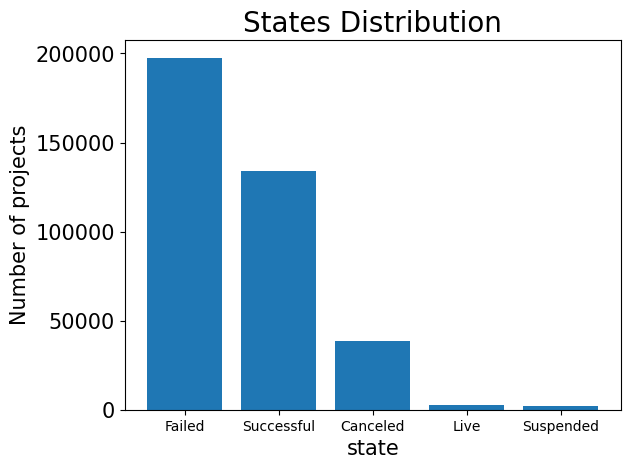

In [428]:
plt.bar(x = states.index, height = states.values)
plt.title('States Distribution')
plt.ylabel('Number of projects')
plt.xlabel('state')
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=15) 
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize = 15)

In [429]:
# We could remove Live and Suspended, as they have betwen 0.4 and 0.7 % of the data.
# Suspended project broke kickstarter rules
# but "Canceled" doesn't tell us if it's successful or failed and it's 10% of the data
# let's flag Canceled as Failed
data['state'].value_counts(normalize=True)

state
Failed        0.527169
Successful    0.357076
Canceled      0.103377
Live          0.007464
Suspended     0.004914
Name: proportion, dtype: float64

In [430]:
# 0 = Failed + Canceled
# 1 = Successful
df = data.copy()
df['state'] = (df['state'] == 'Successful')*1
df['state'].value_counts(normalize=True)

state
0    0.642924
1    0.357076
Name: proportion, dtype: float64

3. Train/Test split

In [431]:
## TO REMOVE ###
# features
X = df.drop('state', axis=1)
X

# target
# 0 = Failed
# 1 = Successful
y = df['state']
y.unique()

array([0, 1])

In [432]:
# split
df_train, df_test= train_test_split(
    df,
    test_size=0.3,
    stratify = df.state,
    random_state = RSEED 
    )

# we stratefy the target variable: it ensures the data distributions in the training and test sets are nearly the same.
# This is useful because the data distribution we want to apply the model to later should be identical to the one we train the model on.

In [433]:
# Print shape of datasets
print('Train data')
print('# df_train:     {}'.format(df_train.shape[0]))
print('==================')
print('Test data')
print('# df_test:     {}'.format(df_test.shape[0]))

Train data
# df_train:     262397
Test data
# df_test:     112456


In [434]:
# 262 397 + 112 456 = 374 853
df.shape

(374853, 11)

<Axes: xlabel='state', ylabel='count'>

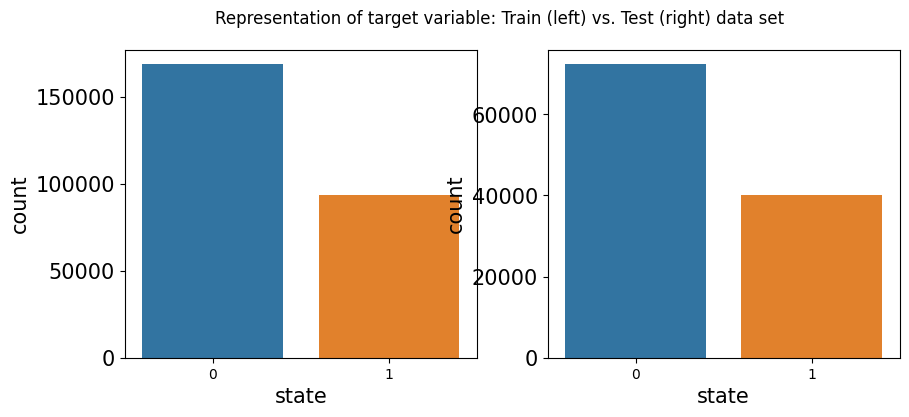

In [435]:
# Visualize y_train and y_test
# Same distribution of target "state" in train and test
fig, axes = plt.subplots(1,2, figsize=(10, 4))
fig.suptitle("Representation of target variable: Train (left) vs. Test (right) data set")
sns.countplot(x=df_train.state, ax=axes[0])
sns.countplot(x=df_test.state, ax=axes[1])

4. Exploration and Cleaning

In [436]:
df_train.head()

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration
16379,Music,Jazz,United States,2011-03-17,2011-05-02,5000,6151,97,1,2011,46
155125,Fashion,Apparel,Australia,2014-07-15,2014-08-14,6525,1762,19,0,2014,30
328113,Games,Tabletop Games,United Kingdom,2017-02-08,2017-03-10,243,1137,18,1,2017,30
318458,Food,Small Batch,United States,2016-11-25,2016-12-25,10000,10193,82,1,2016,30
364530,Games,Tabletop Games,United Kingdom,2017-10-13,2017-11-12,3299,947,16,0,2017,30


In [437]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262397 entries, 16379 to 117466
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   category     262397 non-null  object        
 1   subcategory  262397 non-null  object        
 2   country      262397 non-null  object        
 3   launched     262397 non-null  datetime64[ns]
 4   deadline     262397 non-null  datetime64[ns]
 5   goal         262397 non-null  int64         
 6   pledged      262397 non-null  int64         
 7   backers      262397 non-null  int64         
 8   state        262397 non-null  int64         
 9   year         262397 non-null  int32         
 10  duration     262397 non-null  int64         
dtypes: datetime64[ns](2), int32(1), int64(5), object(3)
memory usage: 23.0+ MB


In [438]:
# Grouping features

# 1. Continuous Numerical features
# goal
# pledged

# 2. Discrete numeric features
# launched
# deadline
# year
# backers
# duration
# goal_achievement

# 3. Categorical (non binary features)
# category
# subcategory
# country

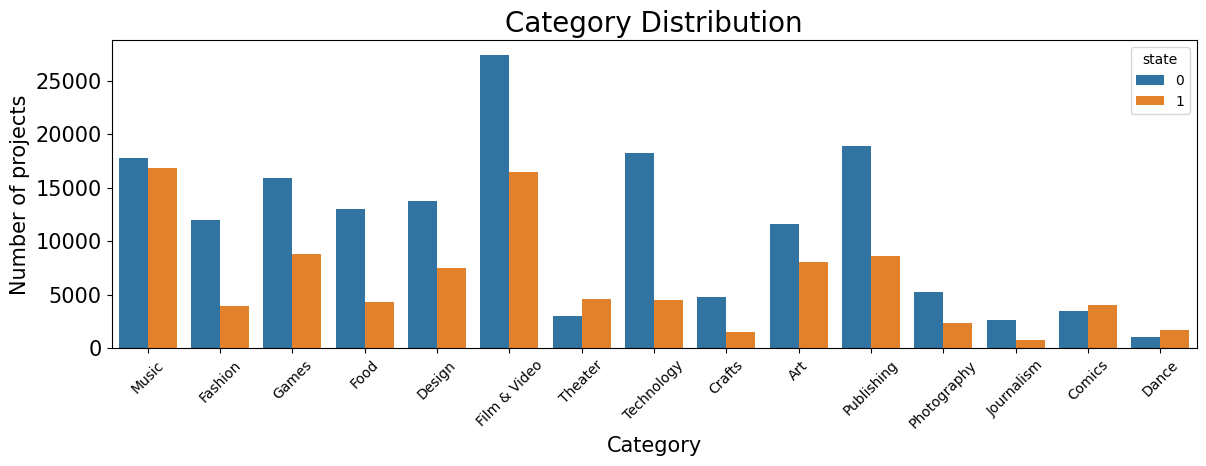

In [439]:
# 3. Categorical
# Category

fig, ax = plt.subplots(1, figsize = (14, 4))

sns.countplot(data = df_train, x = 'category', hue='state')
plt.title('Category Distribution')
plt.ylabel('Number of projects')
plt.xlabel('Category')
plt.rc('xtick', labelsize=10) 
plt.xticks(rotation =45)
plt.rc('ytick', labelsize=15) 
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize = 15)

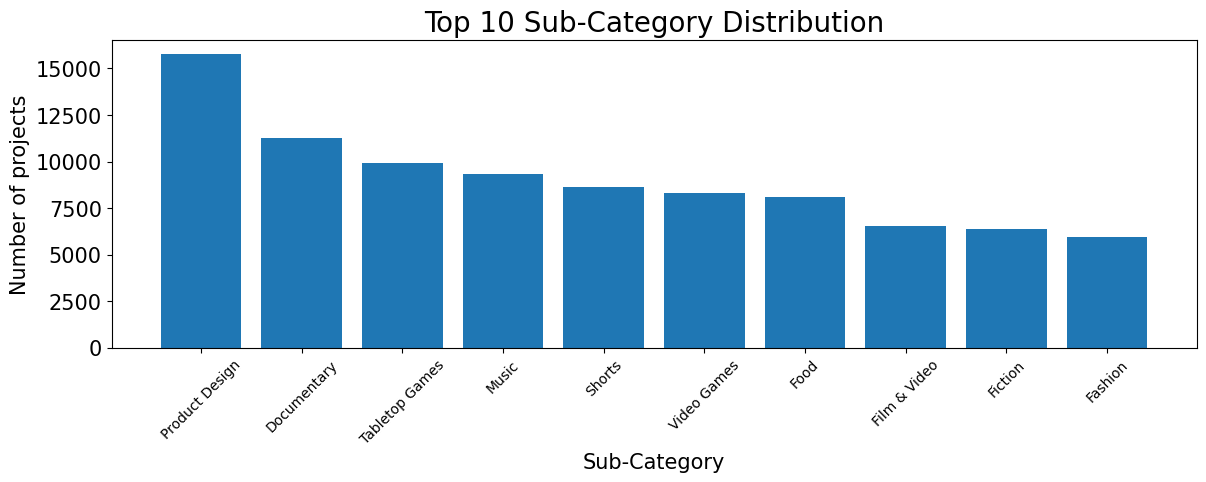

In [440]:
# 3. Categorical
# Subcategory

subcategory = df_train['subcategory'].value_counts()
fig, ax = plt.subplots(1, figsize = (14, 4))

ax.bar(x = subcategory.index[:10], height = subcategory.values[:10])
plt.title('Top 10 Sub-Category Distribution')
plt.ylabel('Number of projects')
plt.xlabel('Sub-Category')
plt.xticks(rotation =45)
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=15) 
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize = 15)

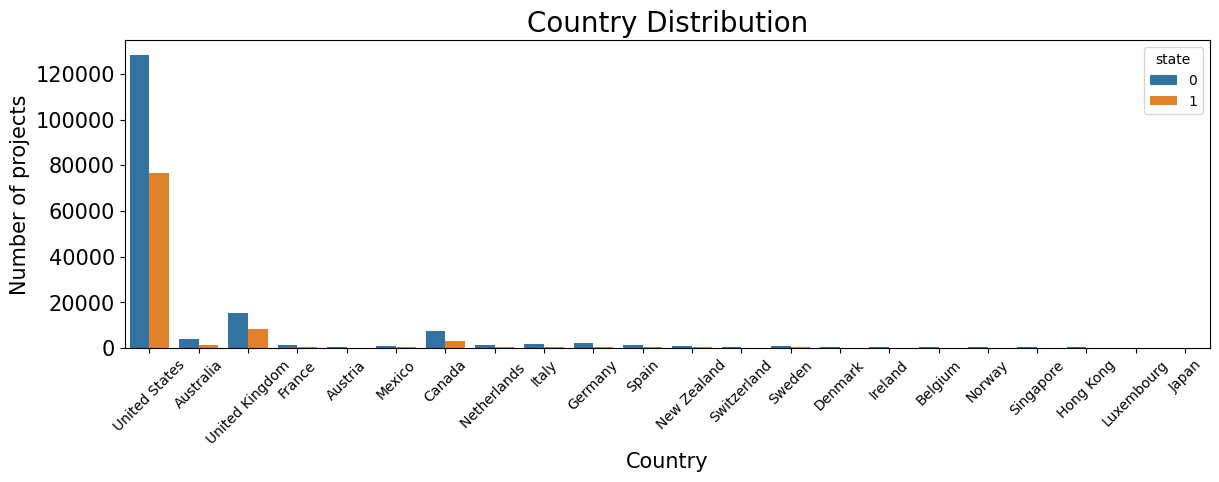

In [441]:
# 3. Categorical
# Country
fig, ax = plt.subplots(1, figsize = (14, 4))

sns.countplot(data = df_train, x = 'country', hue='state')
plt.title('Country Distribution')
plt.ylabel('Number of projects')
plt.xlabel('Country')
plt.rc('xtick', labelsize=10) 
plt.xticks(rotation =45)
plt.rc('ytick', labelsize=15) 
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize = 15)

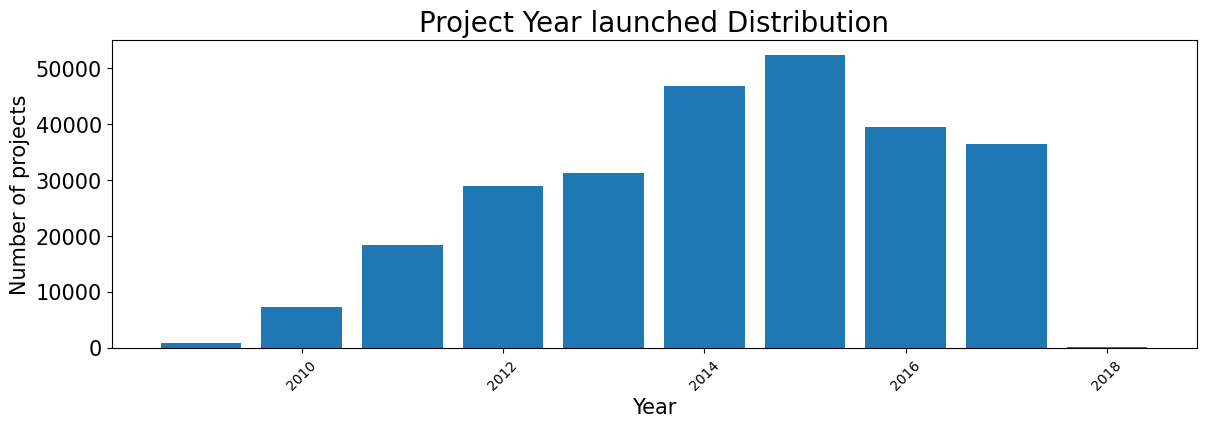

In [442]:
# Numerical
# Year

year= df_train['year'].value_counts()
fig, ax = plt.subplots(1, figsize = (14, 4))

ax.bar(x = year.index, height = year.values)
plt.title('Project Year launched Distribution')
plt.ylabel('Number of projects')
plt.xlabel('Year')
plt.rc('xtick', labelsize=10) 
plt.xticks(rotation =45)
plt.rc('ytick', labelsize=15) 
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize = 15)

In [443]:
num_cols = df.select_dtypes(include='number').columns
num_cols = num_cols.drop('state')
num_cols

Index(['goal', 'pledged', 'backers', 'year', 'duration'], dtype='object')

In [444]:
# descriptive statistics
df_train.describe().T

# probably have missing values:
# goal ?
# pledged ?
# backers ?
# duration ?
# goal_achievement = inf = NaN

,count,mean,min,25%,50%,75%,max,std
launched,262397,2014-09-25 06:42:47.581184256,2009-04-21 00:00:00,2013-04-30 00:00:00,2014-12-01 00:00:00,2016-03-28 00:00:00,2018-01-02 00:00:00,NaN
deadline,262397,2014-10-29 11:28:19.606321408,2009-05-03 00:00:00,2013-06-01 00:00:00,2015-01-04 00:00:00,2016-05-01 00:00:00,2018-03-03 00:00:00,NaN
goal,262397.0,45212.178992,0.0,2000.0,5500.0,16000.0,166361391.0,1188170.67047
pledged,262397.0,9162.188565,0.0,31.0,624.0,4061.0,20338986.0,94722.830393
backers,262397.0,106.488085,0.0,2.0,12.0,57.0,219382.0,927.315865
state,262397.0,0.357077,0.0,0.0,0.0,1.0,1.0,0.479139
year,262397.0,2014.239488,2009.0,2013.0,2014.0,2016.0,2018.0,1.931493
duration,262397.0,34.198287,1.0,30.0,30.0,37.0,92.0,12.779911


In [445]:
# Plot distribution of features 
#features = df_train.columns.tolist()
#features.remove('state')

# fig,ax = plt.subplots(3,4,figsize=(16,12))
# count = 0
# for item in features:
#     sns.histplot(df_train[item], kde=True, ax=ax[int(count/3)][count%3], color='#33658A').set(title=item, xlabel='')
#     count += 1
# ax.flat[-1].set_visible(False)
# fig.tight_layout(pad=3)


In [446]:
# Plot distribution of numerical features
# goal
# pledged
# backers
# duration
# launched
# deadline
# year

#plot_num = ['goal', 'pledged', 'backers', 'duration','launched','deadline','year']


#num_cols = df.select_dtypes(include='number').columns

#for col in num_cols:
#    sns.histplot(df[col], kde=True)
#    plt.title(f'Distribution of {col}')
#    plt.show()
    

In [447]:
# The distributions of:
# 
# 
# are positively/right skewed.
# Transforming them might increase our model's performance (depending on the model type we use).

In [448]:
# The features:
# 
# 
# include zeros, even if it is not a expected value for those features.
# This might indicate, that missing values are represented as zeros in this dataset.
# We have to find a suitable strategy to replace/impute those values.

4.2 Transformation

5.  Analysis of missing values

In [449]:
# Check for missing data
df_train.isnull().sum()

category       0
subcategory    0
country        0
launched       0
deadline       0
goal           0
pledged        0
backers        0
state          0
year           0
duration       0
dtype: int64

In [450]:
# descriptive statistics
df_train.describe().T

# probably have missing values:
# goal:  4 rows with 0 => dropped
# pledged: we keep
# backers: we keep
# duration ?
# goal_achievement: 2 NaN => dropped

,count,mean,min,25%,50%,75%,max,std
launched,262397,2014-09-25 06:42:47.581184256,2009-04-21 00:00:00,2013-04-30 00:00:00,2014-12-01 00:00:00,2016-03-28 00:00:00,2018-01-02 00:00:00,NaN
deadline,262397,2014-10-29 11:28:19.606321408,2009-05-03 00:00:00,2013-06-01 00:00:00,2015-01-04 00:00:00,2016-05-01 00:00:00,2018-03-03 00:00:00,NaN
goal,262397.0,45212.178992,0.0,2000.0,5500.0,16000.0,166361391.0,1188170.67047
pledged,262397.0,9162.188565,0.0,31.0,624.0,4061.0,20338986.0,94722.830393
backers,262397.0,106.488085,0.0,2.0,12.0,57.0,219382.0,927.315865
state,262397.0,0.357077,0.0,0.0,0.0,1.0,1.0,0.479139
year,262397.0,2014.239488,2009.0,2013.0,2014.0,2016.0,2018.0,1.931493
duration,262397.0,34.198287,1.0,30.0,30.0,37.0,92.0,12.779911


In [451]:
## goal cleaning
# only 4 rows with goal = 0
# we remove them
df_train[df_train['goal'] == 0]

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration
40294,Film & Video,Shorts,United States,2012-01-25,2012-03-16,0,0,0,0,2012,51
1085,Art,Conceptual Art,United States,2009-11-25,2009-12-04,0,100,6,1,2009,9
316197,Art,Art,Mexico,2016-11-11,2016-11-12,0,16,7,1,2016,1
33831,Publishing,Fiction,United States,2011-11-07,2011-12-13,0,0,0,0,2011,36


In [452]:
df_train = df_train[df_train['goal']!= 0]
df_train.reset_index(drop=True) 

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration
0,Music,Jazz,United States,2011-03-17,2011-05-02,5000,6151,97,1,2011,46
1,Fashion,Apparel,Australia,2014-07-15,2014-08-14,6525,1762,19,0,2014,30
2,Games,Tabletop Games,United Kingdom,2017-02-08,2017-03-10,243,1137,18,1,2017,30
3,Food,Small Batch,United States,2016-11-25,2016-12-25,10000,10193,82,1,2016,30
4,Games,Tabletop Games,United Kingdom,2017-10-13,2017-11-12,3299,947,16,0,2017,30
...,...,...,...,...,...,...,...,...,...,...,...
262388,Food,Farms,United States,2015-08-31,2015-09-30,8700,2046,15,0,2015,30
262389,Art,Ceramics,United States,2014-08-21,2014-09-20,4500,5117,77,1,2014,30
262390,Theater,Theater,United States,2014-04-19,2014-05-03,1800,1851,23,1,2014,14
262391,Design,Product Design,United Kingdom,2015-11-02,2015-12-02,18168,3985,55,0,2015,30


In [453]:
# Goal Achievement
df_train['goal_achievement'] = ((df_train['pledged'] / df_train['goal']) * 100).round(2)
df_train['goal_achievement']

16379     123.02
155125     27.00
328113    467.90
318458    101.93
364530     28.71
           ...  
244853     23.52
165970    113.71
138707    102.83
256526     21.93
117466     28.90
Name: goal_achievement, Length: 262393, dtype: float64

In [454]:
# it can be true to have 0 pledged
# pledged = 0
df_train[df_train['pledged'] == 0]

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration,goal_achievement
30727,Music,Music,United States,2011-09-28,2011-11-25,2500,0,0,0,2011,58,0.0
195730,Music,Faith,United States,2015-01-24,2015-03-25,1600,0,0,0,2015,60,0.0
202789,Food,Food,United States,2015-02-20,2015-03-22,2000,0,0,0,2015,30,0.0
337375,Publishing,Children's Books,Canada,2017-04-07,2017-05-07,1456,0,0,0,2017,30,0.0
50358,Fashion,Fashion,United States,2012-04-16,2012-06-15,20000,0,0,0,2012,60,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
258868,Art,Art,United States,2015-11-12,2015-12-12,10000,0,0,0,2015,30,0.0
222137,Photography,Places,United States,2015-05-10,2015-06-09,400,0,0,0,2015,30,0.0
221188,Fashion,Jewelry,United States,2015-05-05,2015-06-04,2500,0,0,0,2015,30,0.0
346170,Art,Art,United States,2017-06-05,2017-07-20,800,0,0,0,2017,45,0.0


In [455]:
# it can be true to have 0 backers
# backers= 0
df_train[df_train['backers'] == 0]

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration,goal_achievement
30727,Music,Music,United States,2011-09-28,2011-11-25,2500,0,0,0,2011,58,0.0
195730,Music,Faith,United States,2015-01-24,2015-03-25,1600,0,0,0,2015,60,0.0
202789,Food,Food,United States,2015-02-20,2015-03-22,2000,0,0,0,2015,30,0.0
337375,Publishing,Children's Books,Canada,2017-04-07,2017-05-07,1456,0,0,0,2017,30,0.0
50358,Fashion,Fashion,United States,2012-04-16,2012-06-15,20000,0,0,0,2012,60,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
258868,Art,Art,United States,2015-11-12,2015-12-12,10000,0,0,0,2015,30,0.0
222137,Photography,Places,United States,2015-05-10,2015-06-09,400,0,0,0,2015,30,0.0
221188,Fashion,Jewelry,United States,2015-05-05,2015-06-04,2500,0,0,0,2015,30,0.0
346170,Art,Art,United States,2017-06-05,2017-07-20,800,0,0,0,2017,45,0.0


In [456]:
df_train[df_train['duration'] == 0]

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration,goal_achievement


In [457]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
launched,262393,2014-09-25 06:59:20.390712064,2009-04-21 00:00:00,2013-04-30 00:00:00,2014-12-01 00:00:00,2016-03-28 00:00:00,2018-01-02 00:00:00,NaN
deadline,262393,2014-10-29 11:45:05.518821120,2009-05-03 00:00:00,2013-06-01 00:00:00,2015-01-04 00:00:00,2016-05-01 00:00:00,2018-03-03 00:00:00,NaN
goal,262393.0,45212.868221,1.0,2000.0,5500.0,16000.0,166361391.0,1188179.713777
pledged,262393.0,9162.327795,0.0,31.0,624.0,4061.0,20338986.0,94723.545672
backers,262393.0,106.489659,0.0,2.0,12.0,57.0,219382.0,927.322845
state,262393.0,0.357075,0.0,0.0,0.0,1.0,1.0,0.479138
year,262393.0,2014.239522,2009.0,2013.0,2014.0,2016.0,2018.0,1.931462
duration,262393.0,34.198439,1.0,30.0,30.0,37.0,92.0,12.779707
goal_achievement,262393.0,277.063292,0.0,0.46,13.41,106.55,6876400.0,20855.132029


In [458]:
# outliers ?
df_train[df_train['goal_achievement'] == df_train['goal_achievement'].max()]

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration,goal_achievement
311903,Music,Rock,United States,2016-10-14,2016-12-13,1,68764,955,1,2016,60,6876400.0


In [459]:
# outliers ?
df_train[df_train['goal_achievement'] > 100]

,category,subcategory,country,launched,deadline,goal,pledged,backers,state,year,duration,goal_achievement
16379,Music,Jazz,United States,2011-03-17,2011-05-02,5000,6151,97,1,2011,46,123.02
328113,Games,Tabletop Games,United Kingdom,2017-02-08,2017-03-10,243,1137,18,1,2017,30,467.90
318458,Food,Small Batch,United States,2016-11-25,2016-12-25,10000,10193,82,1,2016,30,101.93
251316,Design,Product Design,France,2015-10-05,2015-12-04,216950,1764897,8330,1,2015,60,813.50
55017,Theater,Theater,United States,2012-05-22,2012-05-31,250,385,8,1,2012,9,154.00
...,...,...,...,...,...,...,...,...,...,...,...,...
349900,Games,Video Games,Canada,2017-06-30,2017-08-01,10340,41654,1621,1,2017,32,402.84
370742,Games,Tabletop Games,United States,2017-11-21,2017-12-05,15000,109892,1027,1,2017,14,732.61
54088,Music,Rock,United States,2012-05-14,2012-06-08,600,1215,33,1,2012,25,202.50
165970,Art,Ceramics,United States,2014-08-21,2014-09-20,4500,5117,77,1,2014,30,113.71


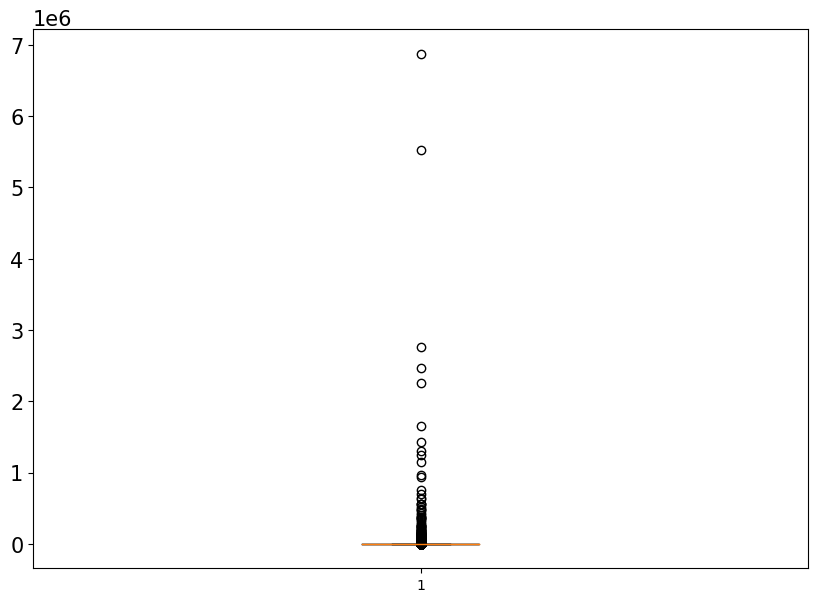

In [460]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df_train['goal_achievement'])
plt.show()

In [461]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
launched,262393,2014-09-25 06:59:20.390712064,2009-04-21 00:00:00,2013-04-30 00:00:00,2014-12-01 00:00:00,2016-03-28 00:00:00,2018-01-02 00:00:00,NaN
deadline,262393,2014-10-29 11:45:05.518821120,2009-05-03 00:00:00,2013-06-01 00:00:00,2015-01-04 00:00:00,2016-05-01 00:00:00,2018-03-03 00:00:00,NaN
goal,262393.0,45212.868221,1.0,2000.0,5500.0,16000.0,166361391.0,1188179.713777
pledged,262393.0,9162.327795,0.0,31.0,624.0,4061.0,20338986.0,94723.545672
backers,262393.0,106.489659,0.0,2.0,12.0,57.0,219382.0,927.322845
state,262393.0,0.357075,0.0,0.0,0.0,1.0,1.0,0.479138
year,262393.0,2014.239522,2009.0,2013.0,2014.0,2016.0,2018.0,1.931462
duration,262393.0,34.198439,1.0,30.0,30.0,37.0,92.0,12.779707
goal_achievement,262393.0,277.063292,0.0,0.46,13.41,106.55,6876400.0,20855.132029


In [462]:
# log on goal, pledged and backers
df_train["log_goal"]         = np.log1p(df_train["goal"]) 
df_train["log_pledged"]      = np.log1p(df_train["pledged"])
df_train["log_backers"]      = np.log1p(df_train["backers"])

In [469]:
df_train.describe().T

,count,mean,min,25%,50%,75%,max,std
launched,262393,2014-09-25 06:59:20.390712064,2009-04-21 00:00:00,2013-04-30 00:00:00,2014-12-01 00:00:00,2016-03-28 00:00:00,2018-01-02 00:00:00,NaN
deadline,262393,2014-10-29 11:45:05.518821120,2009-05-03 00:00:00,2013-06-01 00:00:00,2015-01-04 00:00:00,2016-05-01 00:00:00,2018-03-03 00:00:00,NaN
goal,262393.0,45212.868221,1.0,2000.0,5500.0,16000.0,166361391.0,1188179.713777
pledged,262393.0,9162.327795,0.0,31.0,624.0,4061.0,20338986.0,94723.545672
backers,262393.0,106.489659,0.0,2.0,12.0,57.0,219382.0,927.322845
state,262393.0,0.357075,0.0,0.0,0.0,1.0,1.0,0.479138
year,262393.0,2014.239522,2009.0,2013.0,2014.0,2016.0,2018.0,1.931462
duration,262393.0,34.198439,1.0,30.0,30.0,37.0,92.0,12.779707
goal_achievement,262393.0,277.063292,0.0,0.46,13.41,106.55,6876400.0,20855.132029
log_goal,262393.0,8.642681,0.693147,7.601402,8.612685,9.680406,18.929673,1.695255


6. Corrolations

In [463]:
# sns.pairplot(df_train[["goal", "pledged", "backers", "year", "duration", "state"]], hue="state")

In [464]:
# df.corr().sort_values('state')

In [465]:
# # Calculate correlations between features
# corr = df_train[num_cols].corr()

# plt.subplots(figsize=(15, 12))
# mask = np.triu(np.ones_like(corr, dtype=bool))
# sns.heatmap(corr, annot=True, cmap="YlGnBu_r", mask=mask, vmax=1, vmin=-1);

7. Preparing the Test Set

8. Scaling the Data

In [466]:
# Split into features and target 
X_train = df_train.drop("state", axis=1)
y_train = df_train.state
print(X_train.shape)

(262393, 14)


In [467]:
# Split test set into features and target
X_test = df_test.drop("state", axis=1)
y_test = df_test.state
print(X_test.shape)

(112456, 10)


In [468]:
# Standardizing the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'Music'

9. Target

In [ ]:
# As we have a binary outcome it is always good practice to analyze how balanced the output classes are.

# Visual representation of target variable
sns.countplot(x=df_train.state).set_title("Representation of target variable")

In [ ]:
# We see the classes can not be considered as balanced and therefore it might help to apply a suitable balancing method. In this case we will use the RandomOverSampler() from the imblearn package.
# Oversample training data
ros = RandomOverSampler(random_state=42)
X_train_scaled_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

In [ ]:
# Visual representation of resampled target variable
#sns.countplot(x=y_train_ros).set_title("Representation of resampled target variable");

10. Model building and testing

10.1. Baseline Model

10.2. Predictive Modeling